# 📈 Fund Performance Analytics

## Bluestock Fintech Internship

### Objectives

This notebook evaluates the performance of 40 mutual fund schemes using historical NAV data.

### Metrics Covered

- Daily Returns
- Annualized Returns
- CAGR (1Y, 3Y, 5Y)
- Sharpe Ratio
- Sortino Ratio
- Alpha
- Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from scipy.stats import linregress

plt.style.use("ggplot")

In [2]:
fund = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/raw/02_nav_history.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [3]:
print("Fund Master:", fund.shape)
print("NAV History:", nav.shape)
print("Benchmark:", benchmark.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
Benchmark: (8050, 3)


In [4]:
fund.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,14-02-2006,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,01-01-2013,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,09-09-2009,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,01-01-2013,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,30-12-2000,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [5]:
nav.head()

,amfi_code,date,nav
0,119551,03-01-2022,54.3856
1,119551,04-01-2022,54.3474
2,119551,05-01-2022,54.6869
3,119551,06-01-2022,55.4550
4,119551,07-01-2022,55.3692


In [6]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [7]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [8]:
nav["date"] = pd.to_datetime(
    nav["date"],
    dayfirst=True
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"],
    dayfirst=True
)

ValueError: unconverted data remains when parsing with format "%Y-%d-%m": "3", at position 8. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [9]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"],
    format="mixed"
)

In [10]:
benchmark.head(10)

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15
5,2022-01-10,NIFTY50,18124.84
6,2022-01-11,NIFTY50,18256.96
7,2022-01-12,NIFTY50,18162.54
8,2022-01-13,NIFTY50,18179.05
9,2022-01-14,NIFTY50,17971.75


In [11]:
# Calculate daily return for each fund

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [12]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,119551,2022-01-03,54.3856,NaN
1,119551,2022-01-04,54.3474,-0.000702
2,119551,2022-01-05,54.6869,0.006247
3,119551,2022-01-06,55.4550,0.014045
4,119551,2022-01-07,55.3692,-0.001547
5,119551,2022-01-10,55.2835,-0.001548
6,119551,2022-01-11,56.0878,0.014549
7,119551,2022-01-12,56.4978,0.007310
8,119551,2022-01-13,56.2934,-0.003618
9,119551,2022-01-14,56.5926,0.005315


In [13]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [14]:
import plotly.express as px

fig = px.histogram(
    nav,
    x="daily_return",
    nbins=100,
    title="Distribution of Daily Returns"
)

fig.show()

In [15]:
from pathlib import Path

output_dir = Path("../outputs")
output_dir.mkdir(exist_ok=True)

nav.to_csv(
    output_dir / "returns_computed.csv",
    index=False
)

print("✅ returns_computed.csv saved successfully!")

✅ returns_computed.csv saved successfully!


In [16]:
cagr_df = nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [17]:
def calculate_cagr(group, years):
    group = group.sort_values("date")

    end_date = group["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    period = group[group["date"] >= start_date]

    if len(period) < 2:
        return np.nan

    start_nav = period.iloc[0]["nav"]
    end_nav = period.iloc[-1]["nav"]

    cagr = (end_nav / start_nav) ** (1 / years) - 1

    return cagr * 100

In [18]:
results = []

for code, group in cagr_df.groupby("amfi_code"):

    results.append({
        "amfi_code": code,
        "scheme_name": group["scheme_name"].iloc[0],
        "CAGR_1Y": calculate_cagr(group, 1),
        "CAGR_3Y": calculate_cagr(group, 3),
        "CAGR_5Y": calculate_cagr(group, 5)
    })

cagr_report = pd.DataFrame(results)

In [19]:
cagr_report.head()

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.224271,1.292649,2.316843
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.704969,3.916390,3.912653
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,26.074068
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,20.442730
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.986032,-4.152381,6.953336


In [20]:
output_dir.mkdir(exist_ok=True)

cagr_report.to_csv(
    output_dir / "cagr_report.csv",
    index=False
)

print("✅ cagr_report.csv saved successfully!")

✅ cagr_report.csv saved successfully!


In [21]:
nav["date"].min(), nav["date"].max()

(Timestamp('2022-01-03 00:00:00'), Timestamp('2026-05-29 00:00:00'))

### Note

The available NAV history spans from **03-Jan-2022** to **29-May-2026** (approximately 4.4 years).

Therefore:
- 1-Year CAGR has been computed.
- 3-Year CAGR has been computed.
- 5-Year CAGR cannot be computed due to insufficient historical data and is reported as NaN.

In [22]:
cagr_report.head()

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.224271,1.292649,2.316843
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.704969,3.916390,3.912653
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,26.074068
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,20.442730
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.986032,-4.152381,6.953336


In [23]:
cagr_report.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   amfi_code    40 non-null     int64  
 1   scheme_name  40 non-null     object 
 2   CAGR_1Y      40 non-null     float64
 3   CAGR_3Y      40 non-null     float64
 4   CAGR_5Y      40 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 1.7+ KB


In [24]:
cagr_report.isna().sum()

amfi_code      0
scheme_name    0
CAGR_1Y        0
CAGR_3Y        0
CAGR_5Y        0
dtype: int64

In [25]:
cagr_report.head(10)

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.224271,1.292649,2.316843
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.704969,3.916390,3.912653
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,26.074068
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,20.442730
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.986032,-4.152381,6.953336
5,101208,ABSL Liquid Fund - Regular - Growth,7.236645,6.315784,5.705734
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,20.207704,19.667262,15.878823
7,102886,UTI Mid Cap Fund - Regular - Growth,-16.797481,-0.767406,1.030350
8,102887,UTI Flexi Cap Fund - Regular - Growth,13.583135,25.556188,14.678110
9,118632,Nippon India Large Cap Fund - Regular - Growth,33.981048,22.652360,20.881118


In [26]:
rf = 0.065  # Annual risk-free rate (6.5%)

In [27]:
sharpe_list = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) == 0:
        continue

    # Annualized return
    annual_return = returns.mean() * 252

    # Annualized volatility
    annual_std = returns.std() * np.sqrt(252)

    # Sharpe Ratio
    sharpe = (annual_return - rf) / annual_std

    sharpe_list.append({
        "amfi_code": code,
        "Sharpe_Ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_list)

In [28]:
sharpe_df = sharpe_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [29]:
sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,Sharpe_Ratio,scheme_name
34,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,1.306744,Kotak Flexicap Fund - Regular - Growth
36,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.132122,DSP Midcap Fund - Regular - Growth
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,1.081659,Nippon India Large Cap Fund - Regular - Growth
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
24,120504,1.026524,ICICI Pru Bluechip Fund - Direct - Growth


In [30]:
from pathlib import Path

output_dir = Path("../outputs")
output_dir.mkdir(exist_ok=True)

sharpe_df.to_csv(
    output_dir / "sharpe_values.csv",
    index=False
)

print("✅ sharpe_values.csv saved successfully!")

✅ sharpe_values.csv saved successfully!


In [31]:
import plotly.express as px

top10 = sharpe_df.head(10)

fig = px.bar(
    top10,
    x="Sharpe_Ratio",
    y="scheme_name",
    orientation="h",
    title="Top 10 Funds by Sharpe Ratio",
    text="Sharpe_Ratio"
)

fig.update_layout(yaxis={"categoryorder": "total ascending"})

fig.show()

In [32]:
rf = 0.065

In [33]:
sortino_list = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) == 0:
        continue

    annual_return = returns.mean() * 252

    downside_returns = returns[returns < 0]

    if len(downside_returns) == 0:
        sortino = np.nan
    else:
        downside_std = downside_returns.std() * np.sqrt(252)
        sortino = (annual_return - rf) / downside_std

    sortino_list.append({
        "amfi_code": code,
        "Sortino_Ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_list)

In [34]:
sortino_df = sortino_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [35]:
sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,Sortino_Ratio,scheme_name
34,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,2.364320,Kotak Flexicap Fund - Regular - Growth
36,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.875101,DSP Midcap Fund - Regular - Growth
9,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth


In [36]:
sortino_df.to_csv(
    "../outputs/sortino_values.csv",
    index=False
)

print("✅ sortino_values.csv saved!")

✅ sortino_values.csv saved!


In [37]:
top10 = sortino_df.head(10)

fig = px.bar(
    top10,
    x="Sortino_Ratio",
    y="scheme_name",
    orientation="h",
    title="Top 10 Funds by Sortino Ratio",
    text="Sortino_Ratio"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"}
)

fig.show()

In [38]:
from scipy.stats import linregress

In [39]:
beta = slope
alpha = intercept * 252

NameError: name 'slope' is not defined

In [1]:
benchmark["index_name"].value_counts()

NameError: name 'benchmark' is not defined

In [3]:
import pandas as pd
import numpy as np

In [4]:
benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [5]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"],
    format="mixed"
)

benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [6]:
print(nav.head())
print(fund.head())

NameError: name 'nav' is not defined

In [7]:
# Reload fund and NAV data after kernel restart

fund = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

nav = pd.read_csv(
    "../data/processed/nav_history_cleaned.csv"
)

print("Fund:")
print(fund.head())

print("\nNAV:")
print(nav.head())

Fund:
   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  14-02-2006              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  01-01-2013              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  09-09-2009       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  01-01-2013       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  30-12-2000  CRISIL Dynamic Gilt Index   

   expense_ratio_pct  exit_load_pct  min_sip_amount  min_lumpsum_amo

In [8]:
nav["date"] = pd.to_datetime(
    nav["date"],
    format="mixed"
)

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [9]:
print("NAV rows:", len(nav))
print("Funds:", fund["amfi_code"].nunique())
print("Benchmark rows:", len(benchmark))

print("\nNAV columns:")
print(nav.columns.tolist())

NAV rows: 46000
Funds: 40
Benchmark rows: 8050

NAV columns:
['amfi_code', 'date', 'nav', 'daily_return']


In [10]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
][["date", "benchmark_return"]].copy()

print(nifty100.head())
print("NIFTY 100 rows:", len(nifty100))

           date  benchmark_return
1150 2022-01-03               NaN
1151 2022-01-04         -0.013540
1152 2022-01-05          0.004003
1153 2022-01-06         -0.002935
1154 2022-01-07          0.006150
NIFTY 100 rows: 1150


In [11]:
from scipy.stats import linregress

alpha_beta_list = []

for code, group in nav.groupby("amfi_code"):

    fund_returns = group[
        ["date", "daily_return"]
    ].dropna()

    merged = fund_returns.merge(
        nifty100,
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 30:
        continue

    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta_list.append({
        "amfi_code": code,
        "alpha": regression.intercept * 252,
        "beta": regression.slope,
        "r_squared": regression.rvalue ** 2,
        "p_value": regression.pvalue
    })

alpha_beta_df = pd.DataFrame(alpha_beta_list)

In [12]:
alpha_beta_df = alpha_beta_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

alpha_beta_df.head(10)

,amfi_code,alpha,beta,r_squared,p_value,scheme_name
0,100016,0.037476,-0.058268,0.002665,0.080264,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,0.000015,0.897012,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,0.000012,0.906369,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,0.000348,0.527551,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,0.001064,0.269234,ABSL Small Cap Fund - Regular - Growth
5,101208,0.060861,0.000267,0.000046,0.818214,ABSL Liquid Fund - Regular - Growth
6,102885,0.170488,-0.019487,0.000383,0.507595,UTI Nifty 50 Index Fund - Regular - Growth
7,102886,0.028969,-0.042125,0.000896,0.310578,UTI Mid Cap Fund - Regular - Growth
8,102887,0.162113,0.016683,0.000186,0.644047,UTI Flexi Cap Fund - Regular - Growth
9,118632,0.218294,-0.008354,0.000058,0.796646,Nippon India Large Cap Fund - Regular - Growth


In [13]:
alpha_beta_df.to_csv(
    "../outputs/alpha_beta.csv",
    index=False
)

print("✅ alpha_beta.csv saved successfully!")

✅ alpha_beta.csv saved successfully!


In [14]:
nifty100["benchmark_return"].describe()

count    1149.000000
mean        0.000122
std         0.008119
min        -0.026873
25%        -0.005385
50%        -0.000112
75%         0.005456
max         0.026795
Name: benchmark_return, dtype: float64

In [15]:
print(nifty100.shape)
print(nifty100.head())

(1150, 2)
           date  benchmark_return
1150 2022-01-03               NaN
1151 2022-01-04         -0.013540
1152 2022-01-05          0.004003
1153 2022-01-06         -0.002935
1154 2022-01-07          0.006150


In [16]:
print(benchmark["index_name"].unique())

['BSE_SMALLCAP' 'CRISIL_GILT' 'CRISIL_LIQUID' 'NIFTY100' 'NIFTY50'
 'NIFTY500' 'NIFTY_MIDCAP150']


In [17]:
drawdown_list = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (
        group["nav"] / group["running_max"] - 1
    )

    # Worst drawdown
    min_idx = group["drawdown"].idxmin()

    max_drawdown = group.loc[min_idx, "drawdown"]
    trough_date = group.loc[min_idx, "date"]

    # Peak date before the trough
    peak_data = group[
        group["date"] <= trough_date
    ]

    peak_idx = peak_data["nav"].idxmax()
    peak_date = group.loc[peak_idx, "date"]

    drawdown_list.append({
        "amfi_code": code,
        "max_drawdown_pct": max_drawdown * 100,
        "peak_date": peak_date,
        "trough_date": trough_date
    })

drawdown_df = pd.DataFrame(drawdown_list)

In [18]:
drawdown_df = drawdown_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [19]:
drawdown_df.sort_values(
    "max_drawdown_pct"
).head(10)

,amfi_code,max_drawdown_pct,peak_date,trough_date,scheme_name
22,119599,-52.574221,2023-01-17,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-51.677754,2025-05-22,2026-05-11,Axis Small Cap Fund - Regular - Growth
4,101207,-35.446916,2024-11-21,2026-05-11,ABSL Small Cap Fund - Regular - Growth
39,149324,-31.171900,2024-05-03,2025-01-03,DSP Small Cap Fund - Regular - Growth
21,119598,-28.706006,2024-08-28,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth
7,102886,-28.001124,2025-01-07,2026-04-27,UTI Mid Cap Fund - Regular - Growth
0,100016,-24.734441,2022-03-30,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth
29,120842,-24.003511,2023-11-09,2024-10-17,Kotak Emerging Equity Fund - Regular - Growth
11,118634,-23.344886,2025-04-09,2026-02-20,Nippon India Small Cap Fund - Regular - Growth
15,119093,-21.751396,2022-02-24,2023-05-22,Axis Bluechip Fund - Direct - Growth


In [20]:
drawdown_df.to_csv(
    "../outputs/max_drawdown.csv",
    index=False
)

print("✅ max_drawdown.csv saved successfully!")

✅ max_drawdown.csv saved successfully!


In [21]:
scorecard = (
    cagr_report[["amfi_code", "scheme_name", "CAGR_3Y"]]
    .merge(
        sharpe_df[["amfi_code", "Sharpe_Ratio"]],
        on="amfi_code"
    )
    .merge(
        alpha_beta_df[["amfi_code", "alpha"]],
        on="amfi_code"
    )
    .merge(
        fund[["amfi_code", "expense_ratio_pct"]],
        on="amfi_code"
    )
    .merge(
        drawdown_df[["amfi_code", "max_drawdown_pct"]],
        on="amfi_code"
    )
)

scorecard.head()

NameError: name 'cagr_report' is not defined

In [22]:
import pandas as pd

cagr_report = pd.read_csv("../outputs/cagr_report.csv")
sharpe_df = pd.read_csv("../outputs/sharpe_values.csv")
alpha_beta_df = pd.read_csv("../outputs/alpha_beta.csv")
drawdown_df = pd.read_csv("../outputs/max_drawdown.csv")
fund = pd.read_csv("../data/raw/07_scheme_performance.csv")

print("All files loaded successfully!")

All files loaded successfully!


In [23]:
print(cagr_report.columns.tolist())
print(sharpe_df.columns.tolist())
print(alpha_beta_df.columns.tolist())
print(drawdown_df.columns.tolist())
print(fund.columns.tolist())

['amfi_code', 'scheme_name', 'CAGR_1Y', 'CAGR_3Y', 'CAGR_5Y']
['amfi_code', 'Sharpe_Ratio', 'scheme_name']
['amfi_code', 'alpha', 'beta', 'r_squared', 'p_value', 'scheme_name']
['amfi_code', 'max_drawdown_pct', 'peak_date', 'trough_date', 'scheme_name']
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [24]:
[c for c in fund.columns if "expense" in c.lower()]

['expense_ratio_pct']

In [25]:
scorecard = (
    cagr_report[["amfi_code", "scheme_name", "CAGR_3Y"]]
    .merge(
        sharpe_df[["amfi_code", "Sharpe_Ratio"]],
        on="amfi_code",
        how="inner"
    )
    .merge(
        alpha_beta_df[["amfi_code", "alpha"]],
        on="amfi_code",
        how="inner"
    )
    .merge(
        fund[["amfi_code", "expense_ratio_pct"]],
        on="amfi_code",
        how="inner"
    )
    .merge(
        drawdown_df[["amfi_code", "max_drawdown_pct"]],
        on="amfi_code",
        how="inner"
    )
)

print(scorecard.shape)
scorecard.head()

(40, 7)


,amfi_code,scheme_name,CAGR_3Y,Sharpe_Ratio,alpha,expense_ratio_pct,max_drawdown_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,1.292649,-0.201517,0.037476,1.55,-24.734441
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.916390,-0.567095,0.042818,0.56,-4.308264
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.442459,1.093699,0.271954,1.38,-16.217209
3,101206,ABSL Frontline Equity Fund - Regular - Growth,28.967695,1.027213,0.213998,1.60,-11.291596
4,101207,ABSL Small Cap Fund - Regular - Growth,-4.152381,0.162661,0.108971,1.53,-35.446916


In [26]:
scorecard["return_score"] = (
    scorecard["CAGR_3Y"].rank(pct=True) * 100
)

scorecard["sharpe_score"] = (
    scorecard["Sharpe_Ratio"].rank(pct=True) * 100
)

scorecard["alpha_score"] = (
    scorecard["alpha"].rank(pct=True) * 100
)

# Lower expense = better
scorecard["expense_score"] = (
    scorecard["expense_ratio_pct"]
    .rank(pct=True, ascending=False) * 100
)

# Less negative drawdown = better
scorecard["drawdown_score"] = (
    scorecard["max_drawdown_pct"].rank(pct=True) * 100
)

In [27]:
scorecard["fund_score"] = (
    0.30 * scorecard["return_score"]
    + 0.25 * scorecard["sharpe_score"]
    + 0.20 * scorecard["alpha_score"]
    + 0.15 * scorecard["expense_score"]
    + 0.10 * scorecard["drawdown_score"]
)

In [28]:
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
).reset_index(drop=True)

scorecard["overall_rank"] = scorecard.index + 1

In [29]:
scorecard[
    [
        "overall_rank",
        "scheme_name",
        "fund_score",
        "CAGR_3Y",
        "Sharpe_Ratio",
        "alpha",
        "expense_ratio_pct",
        "max_drawdown_pct"
    ]
].head(10)

,overall_rank,scheme_name,fund_score,CAGR_3Y,Sharpe_Ratio,alpha,expense_ratio_pct,max_drawdown_pct
0,1,Mirae Asset Large Cap Fund - Regular - Growth,86.2500,34.000916,1.448291,0.269838,1.46,-11.265729
1,2,ICICI Pru Midcap Fund - Regular - Growth,82.2500,31.777537,1.180101,0.292636,1.36,-18.188514
2,3,Kotak Flexicap Fund - Regular - Growth,82.0000,29.582770,1.306744,0.273305,1.45,-12.973968
3,4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.7500,32.442459,1.093699,0.271954,1.38,-16.217209
4,5,ICICI Pru Bluechip Fund - Direct - Growth,80.0000,32.487429,1.026524,0.211948,0.80,-12.588276
5,6,Axis Midcap Fund - Regular - Growth,77.0000,35.111802,0.998231,0.260767,1.38,-20.960884
6,7,SBI Bluechip Fund - Regular Plan - Growth,74.8125,30.456524,1.208267,0.232010,1.54,-15.012385
7,8,Mirae Asset Tax Saver Fund - Regular - Growth,73.6875,29.178902,1.234930,0.282704,1.60,-16.396743
8,9,ABSL Frontline Equity Fund - Regular - Growth,68.1875,28.967695,1.027213,0.213998,1.60,-11.291596
9,10,SBI Small Cap Fund - Regular Plan - Growth,67.3750,26.669922,0.945308,0.303370,1.43,-28.706006


In [30]:
scorecard.to_csv(
    "../outputs/fund_scorecard.csv",
    index=False
)

print("✅ fund_scorecard.csv saved successfully!")

✅ fund_scorecard.csv saved successfully!


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"],
    format="mixed"
)

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [32]:
print(benchmark["index_name"].unique())
print(benchmark["date"].min())
print(benchmark["date"].max())

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']
2022-01-03 00:00:00
2026-05-29 00:00:00


In [33]:
returns_df = pd.read_csv(
    "../outputs/returns_computed.csv"
)

returns_df["date"] = pd.to_datetime(
    returns_df["date"],
    format="mixed"
)

returns_df.head()

,amfi_code,date,nav,daily_return
0,119551,2022-01-03,54.3856,NaN
1,119551,2022-01-04,54.3474,-0.000702
2,119551,2022-01-05,54.6869,0.006247
3,119551,2022-01-06,55.4550,0.014045
4,119551,2022-01-07,55.3692,-0.001547


In [34]:
print(returns_df.columns.tolist())
print(returns_df.shape)

['amfi_code', 'date', 'nav', 'daily_return']
(46000, 4)


In [35]:
top5 = scorecard.head(5)[
    ["amfi_code", "scheme_name"]
]

top5

,amfi_code,scheme_name
0,148567,Mirae Asset Large Cap Fund - Regular - Growth
1,120505,ICICI Pru Midcap Fund - Regular - Growth
2,120843,Kotak Flexicap Fund - Regular - Growth
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
4,120504,ICICI Pru Bluechip Fund - Direct - Growth


In [36]:
benchmark_selected = benchmark[
    benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmark_selected = benchmark_selected.sort_values(
    ["index_name", "date"]
)

benchmark_selected["benchmark_return"] = (
    benchmark_selected
    .groupby("index_name")["close_value"]
    .pct_change()
)

In [37]:
end_date = benchmark_selected["date"].max()

start_date = end_date - pd.DateOffset(years=3)

print("Start:", start_date)
print("End:", end_date)

Start: 2023-05-29 00:00:00
End: 2026-05-29 00:00:00


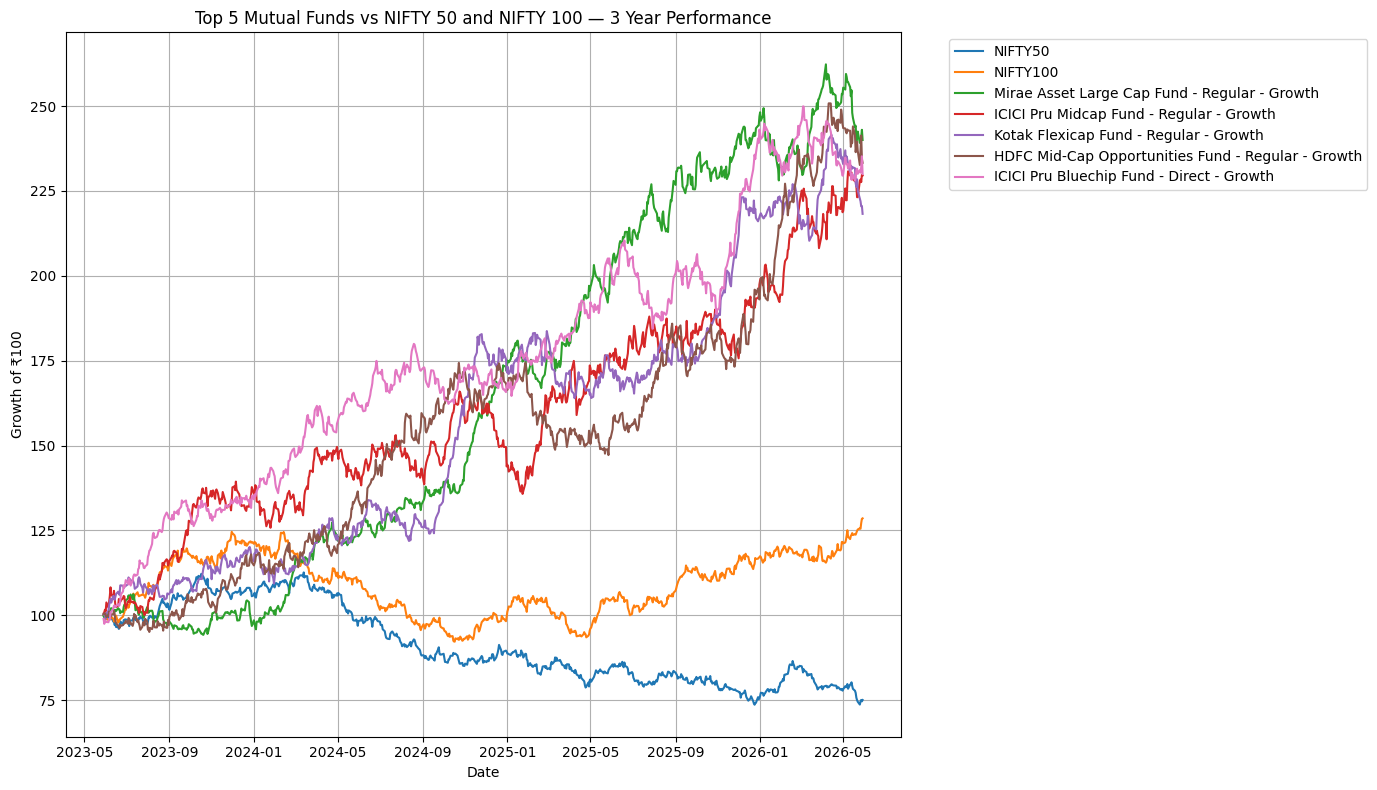

✅ benchmark_chart.png saved successfully!


In [38]:
plt.figure(figsize=(14, 8))

# Benchmark lines
for index_name in ["NIFTY50", "NIFTY100"]:

    b = benchmark_selected[
        (benchmark_selected["index_name"] == index_name) &
        (benchmark_selected["date"] >= start_date)
    ].copy()

    b["normalized"] = (
        b["close_value"] / b["close_value"].iloc[0] * 100
    )

    plt.plot(
        b["date"],
        b["normalized"],
        label=index_name
    )


# Top 5 funds
for _, row in top5.iterrows():

    fund_data = returns_df[
        (returns_df["amfi_code"] == row["amfi_code"]) &
        (returns_df["date"] >= start_date)
    ].copy()

    fund_data = fund_data.sort_values("date")

    # Convert daily returns to cumulative growth
    fund_data["cumulative"] = (
        (1 + fund_data["daily_return"]).cumprod() * 100
    )

    plt.plot(
        fund_data["date"],
        fund_data["cumulative"],
        label=row["scheme_name"]
    )


plt.title("Top 5 Mutual Funds vs NIFTY 50 and NIFTY 100 — 3 Year Performance")
plt.xlabel("Date")
plt.ylabel("Growth of ₹100")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "../outputs/benchmark_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ benchmark_chart.png saved successfully!")

In [39]:
tracking_error_list = []

for _, row in top5.iterrows():

    fund_data = returns_df[
        (returns_df["amfi_code"] == row["amfi_code"]) &
        (returns_df["date"] >= start_date)
    ][["date", "daily_return"]].copy()

    fund_data = fund_data.rename(
        columns={"daily_return": "fund_return"}
    )

    for index_name in ["NIFTY50", "NIFTY100"]:

        b = benchmark_selected[
            (benchmark_selected["index_name"] == index_name) &
            (benchmark_selected["date"] >= start_date)
        ][["date", "benchmark_return"]].copy()

        merged = fund_data.merge(
            b,
            on="date",
            how="inner"
        ).dropna()

        tracking_error = (
            merged["fund_return"] -
            merged["benchmark_return"]
        ).std() * np.sqrt(252)

        tracking_error_list.append({
            "amfi_code": row["amfi_code"],
            "scheme_name": row["scheme_name"],
            "benchmark": index_name,
            "tracking_error": tracking_error
        })

tracking_error_df = pd.DataFrame(tracking_error_list)

tracking_error_df

,amfi_code,scheme_name,benchmark,tracking_error
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY50,0.191817
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY100,0.187867
2,120505,ICICI Pru Midcap Fund - Regular - Growth,NIFTY50,0.228311
3,120505,ICICI Pru Midcap Fund - Regular - Growth,NIFTY100,0.232515
4,120843,Kotak Flexicap Fund - Regular - Growth,NIFTY50,0.204946
5,120843,Kotak Flexicap Fund - Regular - Growth,NIFTY100,0.206410
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY50,0.228081
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY100,0.224838
8,120504,ICICI Pru Bluechip Fund - Direct - Growth,NIFTY50,0.188360
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,NIFTY100,0.187312


In [40]:
tracking_error_df.to_csv(
    "../outputs/tracking_error.csv",
    index=False
)

print("✅ tracking_error.csv saved successfully!")

✅ tracking_error.csv saved successfully!
